Exercise 1

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

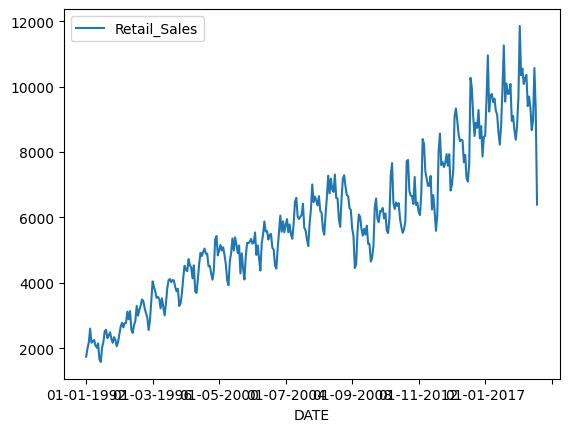

In [ ]:
series2 = pd.read_csv('retail.csv', header=0, index_col=0)
series2.plot()
pyplot.show()

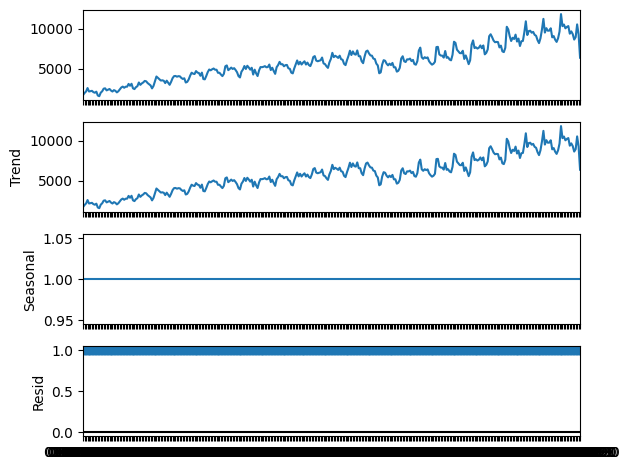

In [ ]:
result2 = seasonal_decompose(series2, model='multiplicative', period=1)
result2.plot()
pyplot.show()

Exercise 2

In [ ]:
product = {'month': [1,2,3,4,5,6,7,8,9,10,11,12], 'demand': [250,235,200,260,279,300,310,305,350,316,350,290]}

In [ ]:
df = pd.DataFrame(product)

/tmp/ipykernel_902/2698155847.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df['month'] = pd.date_range(start='2023-01-01', periods=12, freq='M')
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


Forecasted for next 3 months:
2024-01-31    311.35623
2024-02-29    311.35623
2024-03-31    311.35623
Freq: ME, dtype: float64


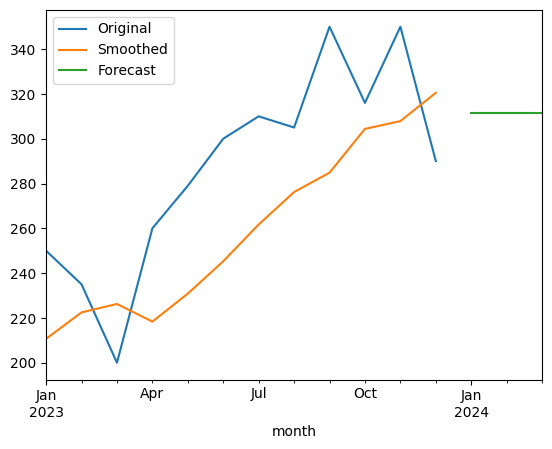

In [ ]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

df['month'] = pd.date_range(start='2023-01-01', periods=12, freq='M')
df.set_index('month', inplace=True)

model = SimpleExpSmoothing(df['demand'], initialization_method='estimated')
model_fit = model.fit(smoothing_level=0.3, optimized=False)
df['SES_fit'] = model_fit.fittedvalues

forecast = model_fit.forecast(3)

print("Forecasted for next 3 months:")
print(forecast)

df['demand'].plot(label='Original')
df['SES_fit'].plot(label='Smoothed')
forecast.plot(label='Forecast')
plt.legend()
plt.show()